In [25]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
traffic_df = pd.DataFrame(traffic_df)

y = traffic_df['traffic_volume']
X = traffic_df.drop('traffic_volume', axis=1)
traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'], format='%d-%m-%Y %H:%M')
traffic_df['hour']=traffic_df['date_time'].dt.hour
#traffic_df['dayOfWeek']=traffic_df['date_time'].dt.weekday
traffic_df['isWeekend'] = (traffic_df['date_time'].dt.weekday >= 5).astype(int)
traffic_df.head(10)

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,hour,isWeekend
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,9,0
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,10,0
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,11,0
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,12,0
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,13,0
5,5181,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,14,0
6,5584,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,15,0
7,6015,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,16,0
8,5791,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,17,0
9,4770,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,18,0


# Dataset analysis and preparation
Since the data is not all numbers, it is required to convert the qualitative categories into quantitative lists.

In [26]:
traffic_df['holiday'].unique()

traffic_df['isHoliday'] = pd.notna(traffic_df['holiday']).astype('int')
print(traffic_df['weather_main'].unique())
# Maybe needed to adapt the order to make sense to the description.
unique_weathers = traffic_df['weather_main'].values
#df['weather_cat'] = pd.factorize(unique_weathers)[0]
weather_encoded = pd.get_dummies(traffic_df['weather_main'], prefix='weather').astype('int')

traffic_df = pd.concat([traffic_df, weather_encoded], axis=1)
traffic_df.head(10)

['Clouds' 'Clear' 'Rain' 'Drizzle' 'Mist' 'Haze' 'Fog' 'Thunderstorm'
 'Snow' 'Squall' 'Smoke']


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,hour,...,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,9,...,1,0,0,0,0,0,0,0,0,0
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,10,...,1,0,0,0,0,0,0,0,0,0
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,11,...,1,0,0,0,0,0,0,0,0,0
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,12,...,1,0,0,0,0,0,0,0,0,0
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,13,...,1,0,0,0,0,0,0,0,0,0
5,5181,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,14,...,0,0,0,0,0,0,0,0,0,0
6,5584,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,15,...,0,0,0,0,0,0,0,0,0,0
7,6015,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,16,...,0,0,0,0,0,0,0,0,0,0
8,5791,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,17,...,1,0,0,0,0,0,0,0,0,0
9,4770,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,18,...,1,0,0,0,0,0,0,0,0,0


Visualization

   traffic_volume holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0            5545     NaN  288.28      0.0      0.0          40       Clouds   
1            4516     NaN  289.36      0.0      0.0          75       Clouds   
2            4767     NaN  289.58      0.0      0.0          90       Clouds   
3            5026     NaN  290.13      0.0      0.0          90       Clouds   
4            4918     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description           date_time  hour  ...  weather_Clouds  \
0    scattered clouds 2012-10-02 09:00:00     9  ...               1   
1       broken clouds 2012-10-02 10:00:00    10  ...               1   
2     overcast clouds 2012-10-02 11:00:00    11  ...               1   
3     overcast clouds 2012-10-02 12:00:00    12  ...               1   
4       broken clouds 2012-10-02 13:00:00    13  ...               1   

   weather_Drizzle  weather_Fog  weather_Haze  weather_Mist  weather_Rain  \
0        

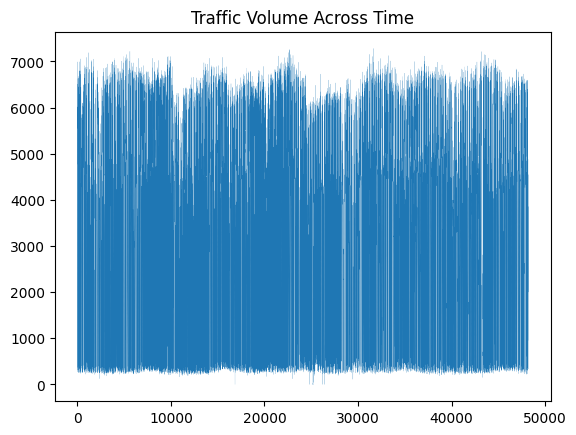

In [27]:
print(traffic_df.head())
#traffic_df.set_index('date_time', inplace = True) # à run qu'une seule fois par df ? jsp pq
plt.plot(traffic_df.index,
         traffic_df['traffic_volume'],
         linewidth = 0.1)
plt.title("Traffic Volume Across Time")
plt.show()


First attempt with the dataset : use only quantitative data

In [28]:
Xp = traffic_df.drop('weather_main', axis=1)
Xp = Xp.drop('date_time', axis=1)
Xp = Xp.drop('weather_description', axis=1)
Xp = Xp.drop('holiday', axis=1)
yp = traffic_df['traffic_volume']
Xp = Xp.drop('traffic_volume', axis=1)
#Xp = Xp.drop('dayOfWeek', axis=1)

print(np.array(Xp))
Xp.describe()

[[288.28   0.     0.   ...   0.     0.     0.  ]
 [289.36   0.     0.   ...   0.     0.     0.  ]
 [289.58   0.     0.   ...   0.     0.     0.  ]
 ...
 [282.73   0.     0.   ...   0.     0.     1.  ]
 [282.09   0.     0.   ...   0.     0.     0.  ]
 [282.12   0.     0.   ...   0.     0.     0.  ]]


,temp,rain_1h,snow_1h,clouds_all,hour,isWeekend,isHoliday,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,11.398162,0.284271,0.001265,0.277799,0.314580,0.037777,0.018920,0.028213,0.123434,0.117667,0.000415,0.059663,0.000083,0.021451
std,13.338232,44.789133,0.008168,39.015750,6.940238,0.451071,0.035551,0.447918,0.464353,0.190658,0.136243,0.165584,0.328938,0.322216,0.020365,0.236864,0.009109,0.144882
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,282.450000,0.000000,0.000000,64.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,291.806000,0.000000,0.000000,90.000000,17.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,310.070000,9831.300000,0.510000,100.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


['temp' 'rain_1h' 'snow_1h' 'clouds_all' 'hour' 'isWeekend' 'isHoliday'
 'weather_Clear' 'weather_Clouds' 'weather_Drizzle' 'weather_Fog'
 'weather_Haze' 'weather_Mist' 'weather_Rain' 'weather_Smoke'
 'weather_Snow' 'weather_Squall' 'weather_Thunderstorm' 'traffic_volume']


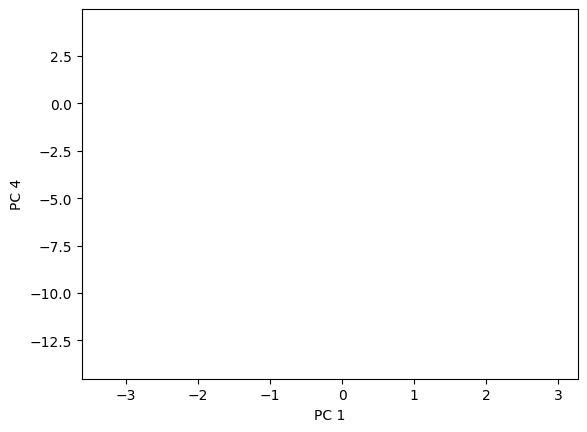

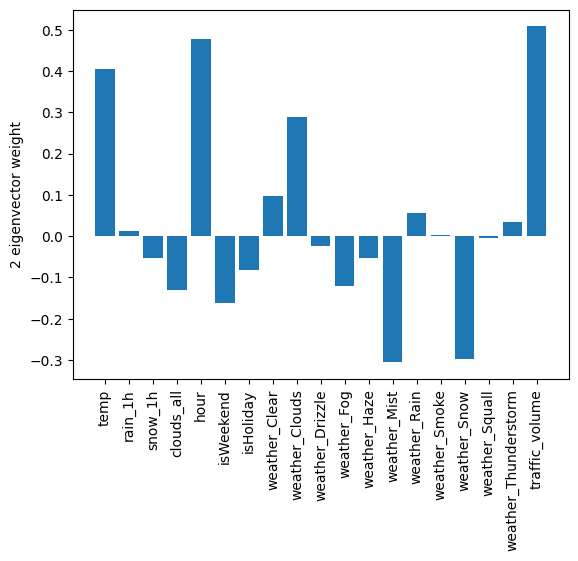

               temp       rain_1h       snow_1h    clouds_all          hour  \
count  48204.000000  48204.000000  48204.000000  48204.000000  48204.000000   
mean     281.205870      0.334264      0.000222     49.362231     11.398162   
std       13.338232     44.789133      0.008168     39.015750      6.940238   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%      272.160000      0.000000      0.000000      1.000000      5.000000   
50%      282.450000      0.000000      0.000000     64.000000     11.000000   
75%      291.806000      0.000000      0.000000     90.000000     17.000000   
max      310.070000   9831.300000      0.510000    100.000000     23.000000   

          isWeekend     isHoliday  weather_Clear  weather_Clouds  \
count  48204.000000  48204.000000   48204.000000    48204.000000   
mean       0.284271      0.001265       0.277799        0.314580   
std        0.451071      0.035551       0.447918        0.464353   
min        0.000

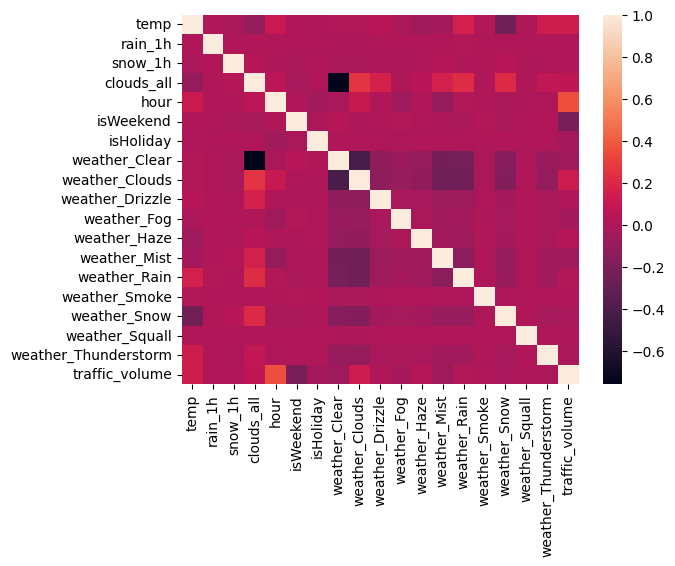

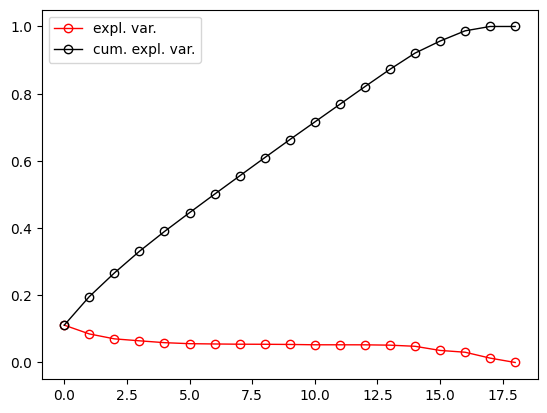

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

df_pca = pd.concat([Xp, yp], axis=1)
X_pca = np.array(df_pca)
traffic_features = df_pca.columns.values
print(traffic_features)
n_features = traffic_features.size

scaler = StandardScaler()
D0 = scaler.fit_transform(X_pca)
pca = PCA(n_components=n_features)
pca.fit(D0)

A = pca.components_.T
Z = D0 @ A

i, j = 0, 3

plt.figure()
plt.scatter(Z[:, i], Z[:, j], c='w')
plt.xlabel(f'PC {i+1}')
plt.ylabel(f'PC {j+1}')
plt.show()

eigenvector_i = 1 # Take the first one

plt.figure()
plt.bar(np.arange(n_features), A[:, eigenvector_i])
plt.xticks(np.arange(n_features), traffic_features, rotation=90)
plt.ylabel(f'{eigenvector_i+1} eigenvector weight')
plt.show()

df_pca = pd.DataFrame(X_pca, columns=traffic_features)
print(df_pca.describe())
corr_mat = sns.heatmap(df_pca.corr())
plt.show()

ex_var = pca.explained_variance_ratio_
cum_ex_var = np.cumsum(ex_var)

plt.figure()
plt.plot(ex_var, marker='o', markerfacecolor='none', color='r', linewidth=1, label='expl. var.')
plt.plot(cum_ex_var, marker='o', markerfacecolor='none', color='k', linewidth=1, label='cum. expl. var.')
plt.legend()
plt.show()


We see that for this dataset, the impact of the day of the week is very week, meaning that traffic is always the same on every day, hence, we can use only the hour from that scope. Holiday is also very week.

For the rest, the most significant parameters are the temp, the clouds and the snow.

Let us know see whether the other categories describing the weather qualitatively are relevant to this study.

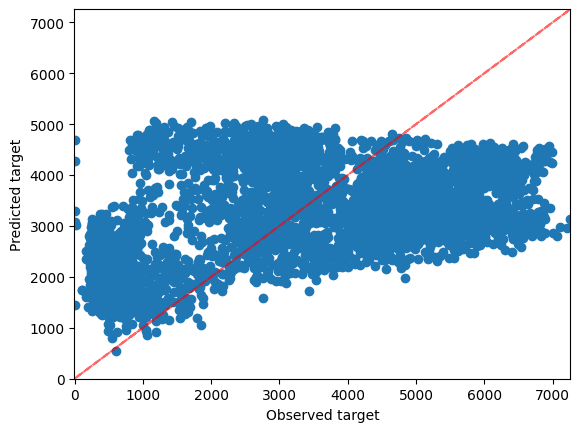

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(Xp, np.array(yp).reshape(-1,1), test_size=0.1, random_state=1)
scalerX = StandardScaler()
scalery = StandardScaler()

X0_train = scalerX.fit_transform(X_train)
X0_test = scalerX.transform(X_test)

# y0_train = scalery.fit_transform(y_train)
# y0_test = scalery.transform(y_test)

# Create the linear regression object
OLS_reg = LinearRegression().fit(X0_train, y_train)

# To test the regression, we need to scale and center also the test data

y_pred_OLS = OLS_reg.predict(X0_test)

plt.scatter(y_test, y_pred_OLS)
plt.plot(y_test, y_test, c='r', alpha=0.6, ls='--')
plt.xlim(y_test.min()-2, y_test.max()+2)
plt.ylim(y_test.min()-2, y_test.max()+2)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2: 0.1775175322416943
RMSE: 1810.049843201465
hour                    650.421656
isWeekend              -427.404381
temp                    202.708928
weather_Clouds          151.275902
clouds_all               82.221813
weather_Haze             64.566456
isHoliday               -53.269340
weather_Thunderstorm    -51.391214
weather_Mist            -20.947706
weather_Clear            15.056510
snow_1h                  -7.617742
weather_Fog              -7.551762
weather_Squall           -5.950004
rain_1h                   3.495974
weather_Rain             -3.371831
weather_Smoke             3.031661
weather_Snow             -0.539024
weather_Drizzle           0.000000
dtype: float64


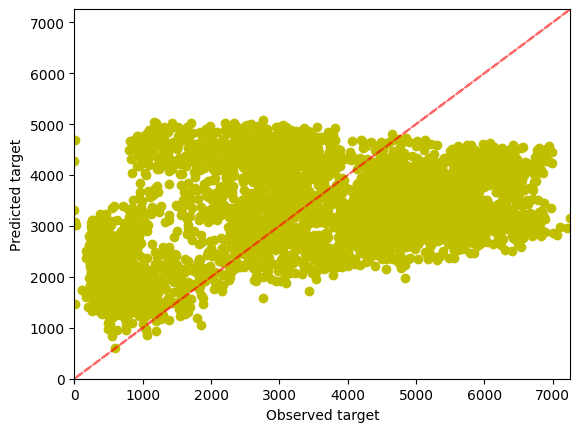

In [31]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error
#print(y0_train)
#print(y0_train.flatten())
LassoCV_reg = LassoCV(cv=10, random_state=42).fit(X0_train, y_train) # Bizarre qu'il faille mettre une tol aussi basse...
y_pred_lassoCV = LassoCV_reg.predict(X0_test)

print("R2:", r2_score(y_test, y_pred_lassoCV))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lassoCV)))

coefficients = pd.Series(LassoCV_reg.coef_, index=Xp.columns)
print(coefficients.sort_values(key=abs, ascending=False))

plt.scatter(y_test, y_pred_lassoCV, c='y', alpha = 1)
plt.plot(y_test, y_test, c='r', alpha=0.6, ls='--')
plt.xlim(y_test.min()-1, y_test.max()+1)
plt.ylim(y_test.min()-1, y_test.max()+1)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()

In [32]:
df_clean = traffic_df.copy()

In [33]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Convert date_time to datetime
df_clean["date_time"] = pd.to_datetime(
    df_clean["date_time"],
    format="mixed",
    dayfirst=True
)

# Extract useful time variables
df_clean["hour"] = df_clean["date_time"].dt.hour
df_clean["day"] = df_clean["date_time"].dt.day
df_clean["month"] = df_clean["date_time"].dt.month
df_clean["weekday"] = df_clean["date_time"].dt.weekday

# Weekend variable
df_clean["weekend"] = df_clean["weekday"].apply(
    lambda x: 1 if x >= 5 else 0
)

# Holiday variable
df_clean["isHoliday"] = (
    df_clean["holiday"] != "None"
).astype(int)

df_clean.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,hour,...,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm,day,month,weekday,weekend
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,9,...,0,0,0,0,0,0,2,10,1,0
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,10,...,0,0,0,0,0,0,2,10,1,0
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,11,...,0,0,0,0,0,0,2,10,1,0
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,12,...,0,0,0,0,0,0,2,10,1,0
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,13,...,0,0,0,0,0,0,2,10,1,0


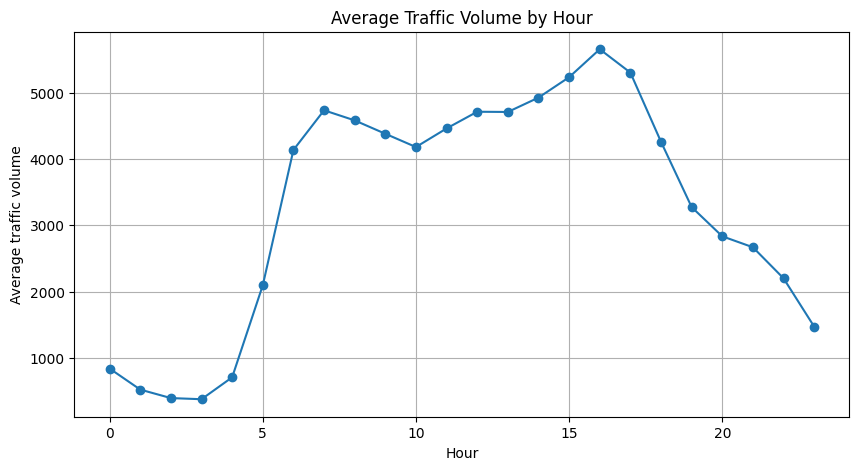

In [34]:
# ============================================================
# RUSH HOUR ANALYSIS
# ============================================================

hourly_traffic = df_clean.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Average traffic volume")
plt.title("Average Traffic Volume by Hour")

plt.grid(True)

plt.show()

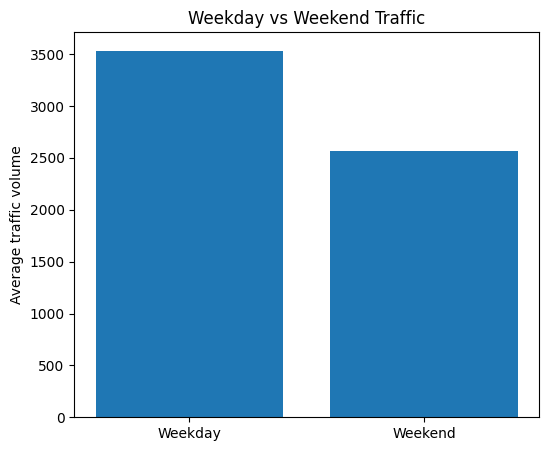

In [35]:
# ============================================================
# WEEKDAY VS WEEKEND
# ============================================================

weekend_traffic = df_clean.groupby("weekend")["traffic_volume"].mean()

plt.figure(figsize=(6,5))

plt.bar(
    ["Weekday", "Weekend"],
    weekend_traffic.values
)

plt.ylabel("Average traffic volume")
plt.title("Weekday vs Weekend Traffic")

plt.show()

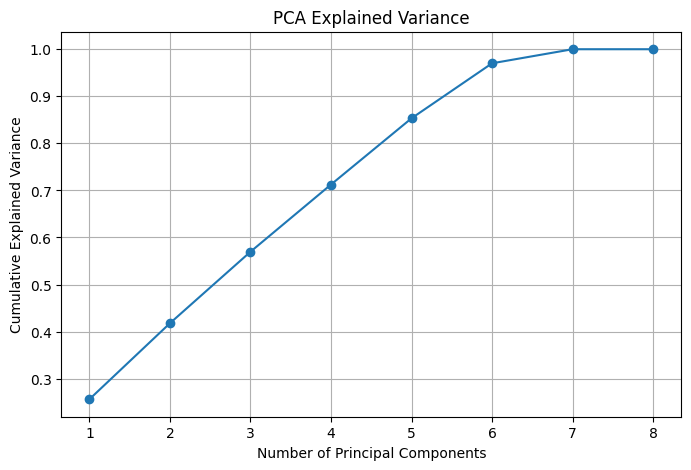

In [36]:
# ============================================================
# PCA ANALYSIS
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "weekday",
    "weekend",
    "isHoliday"
]

X_pca = df_clean[pca_features]

scaler_pca = StandardScaler()

X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA()

X_pca_transformed = pca.fit_transform(X_pca_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [37]:
# PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_features))],
    index=pca_features
)

display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
temp,-0.001440,0.758370,0.028012,-0.029033,0.108190,0.641486,0.006016,0.0
rain_1h,-0.009113,0.050740,0.082552,0.990257,0.093337,-0.034568,0.003541,0.0
snow_1h,-0.029267,-0.165768,0.360674,-0.106937,0.910863,0.021700,-0.000498,0.0
clouds_all,-0.065059,-0.422110,0.646136,0.018166,-0.345241,0.529635,0.008014,0.0
hour,-0.011371,0.464748,0.664128,-0.082054,-0.175229,-0.552608,-0.000872,0.0
weekday,0.705406,-0.018789,0.039742,0.001778,0.003751,0.014875,0.707270,0.0
weekend,0.705052,-0.017333,0.046668,0.006876,0.000801,0.026841,-0.706862,0.0
isHoliday,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,1.0
